## Jupyter notebook

This is a **jupyter notebook** in which you can mix cells of Python code and cell of markdown.

To execute a code in a `cell` you can click on it and then do one of the following:
 - click on the `Run/Play` button in the toolbar
 - click on the menu `Cell > Run Cells`
 - click on the menu `Help > Keyboard shortcuts` to discover that you can also
 - press `Alt`+`Enter`
 - press `Control`+`Enter`


Using the menu `Cell > Cell Type` you can change the content of the cell: either *Code*  or *Markdown*, where Markdown is a simple method to format text (https://en.wikipedia.org/wiki/Markdown). Click on the menu `Help > Markdown` to discover how format a text cell.

The current cell is a *Markdown* one. To access the original Markdown text, double click on this cell.

To pretty visualize this Markdown cell, you have to follow the same steps illustrated above for a code cell, asking for running the cell.


You can UPLOAD and RUN this and other notebooks by using the Google cloud services. For example, open with Chrome and connect with your stud.unive.it account to:  https://colab.research.google.com


 ## Data collection RCV1

To use directly the *RCV1* collection is needed to buy CD-ROMs from Reuters, Ltd. and sign a research agreement.
However, Reuters have stated that distributing term/document matrices is not a violation of the Agreement.

To ensure that the original data cannot be reconstructed, the term/document matrices distributed are built by removing words from a large stop list (including essentially all linguistic function words), replacing the remaining words with stems, and scrambling the order of the stems.

Specifically, Appendix 12 consists of **ten** ASCII files containing tokenized documents.

The files fall in two groups, and the names and the group purposes depend on the usage of RCV1 for text classification, a specific machine learning (ML) task. So the files are subdivided in training and test, as usual for ML predictive tasks.

The following five files contains:
 - 23,149 training documents
 - 781,265 test documents
 - total: 804,414 documents

This collection of five files, known as RCV1-v2, were used to produce the *vectors* in turn exploited for training and testing supervised learners in LYRL2004.

The five compressed files are:
  - lyrl2004_tokens_test_pt0.dat.gz : 44,734,992 Bytes - 199,328 documents
  - lyrl2004_tokens_test_pt1.dat.gz : 45,595,102 Bytes - 199,339 documents
  - lyrl2004_tokens_test_pt2.dat.gz : 44,507,510 Bytes - 199,576 documents
  - lyrl2004_tokens_test_pt3.dat.gz : 42,052,117 Bytes - 183,022 documents
  - lyrl2004_tokens_train.dat.gz :    5,108,963  Bytes - 23,149  documents

Besides the above files, other tokenized documents are provided. Due to the purpose of this colletion, i.e., to provide a collection for text classification, the authors identified many documents in the original RCV1 documents that had demonstrably invalid category codes.
The tokenized files are the following:

  - lyrl2004-non-v2_tokens_test_pt0.dat.gz : 149,887 Bytes - 671 documents
  - lyrl2004-non-v2_tokens_test_pt1.dat.gz : 171,205 Bytes - 661 documents
  - lyrl2004-non-v2_tokens_test_pt2.dat.gz : 102,370 Bytes - 424 documents
  - lyrl2004-non-v2_tokens_test_pt3.dat.gz : 132,291 Bytes - 463 documents
  - lyrl2004-non-v2_tokens_train.dat.gz : 46,419 Bytes - 158 documents

for a total number of documents equal to 2,377.

Finally, we have globally the total number of documents of RCV1: 804,414 + 2,377 = 806,791.


### File format

Each document in a file is represented in a format used by the SMART text retrieval system. A document has the format:



      .I <docid>
      .W
      <textline>+
      <blankline>


where:


      <docid> : Reuters-assigned document id.
      <textline> : A line of white-space separated strings, one for each token
                   produced by preprocessing for the specified document.
                   These lines never begin with a period followed by an upper case alphabetic character.
      <blankline> : A single end of line character.

This is an example of a list of (short) tokenized documents in a given file:

      .I 1
      .W
      now is the time for all good documents
      to come to the aid of the ir community
      
      .I 2
      .W
      i am the best document since i have only one line

      .I 3
      .W
      no i am the best document


For more detail, see the distribution page: http://www.ai.mit.edu/projects/jmlr/papers/volume5/lewis04a/lyrl2004_rcv1v2_README.htm



[LYRL2004] *Lewis, D. D.; Yang, Y.; Rose, T.; and Li, F. RCV1: A New Benchmark Collection for Text Categorization Research. Journal of Machine Learning Research, 5:361-397, 2004. http://www.jmlr.org/papers/volume5/lewis04a/lewis04a.pdf. *


## SPIMI indexer

In [2]:

from os import walk
import numpy as np

'''
    Download the gzip files from:
      http://www.ai.mit.edu/projects/jmlr/papers/volume5/lewis04a/lyrl2004_rcv1v2_README.htm
    as follows:
      lyrl2004_tokens_test_pt0.dat.gz : 149887
      lyrl2004_tokens_test_pt1.dat.gz : 171205
      lyrl2004_tokens_test_pt2.dat.gz : 102370
      lyrl2004_tokens_test_pt3.dat.gz : 132291
      lyrl2004_tokens_train.dat.gz : 46419

    I stored the files in the directory "./FILES" and then decompressed by gunzip
'''

files=[]
for (dirpath, dirnames, filenames) in walk("./FILES/"):
    for f in filenames:
        if '.gz' not in f:    # read only the decompressesd files
            files.append(dirpath + f)



'''
    Return a dictionary where the keys are the terms and the values
    are sorted lists of DocIDs
    The DocID are generated sequentially during the parsing.

    The SPIMI code does not contain the index size check, and does not include
    the final merge step.
'''
def SPIMI_indexer(files):
    dict = {}       # SPIMI (Single-pass in-memory indexing) dictionary

    docid = 0         # counter to assign docids
    tot_docs = 0      # total number of docs
    tot_tokens = 0    # total number of tokens
    tot_postings = 0  # total number of postings

    for f in files:
        print(f)
        count_doc = 0       # number of docs per file .dat
        count_tokens = 0    # number of tokens per file .dat
        count_postings = 0  # number of postings per file .dat

        try:
            file = open(f, 'r',  encoding='utf-8', errors='ignore')

            # Build dict{} of (key:value) pairs
            # key <-  term
            # value <- a list:  [cf, [doc_i1, doc_i2, doc_i3, ...]]
            #          where cf = collection frequency of the term
            #                [doc_i1, doc_i2, ...] are an integer list of DocIDs,
            #                                      sorted by construction

            for line in file:
                ll = line.split()

                if len(ll) != 0:
                    if ll[0] == ".I":         # .I 1
                        count_doc = count_doc + 1
                        docid += 1  # assign sequentially the DocIDs
                        # docid = int(ll[1])  #  docid in the collection
                    elif ll[0] != ".W":       #  != .W  :   <textline>
                        count_tokens += len(ll)
                        for el in ll:
                            if (el in dict):
                                # lenl = len(dict[el][1])     # current len of the posting list
                                dict[el][0] += 1              # increment cf for term el
                                if docid != dict[el][1][-1]:  # check if doc_id was already appended
                                    dict[el][1].append(docid)
                                    count_postings += 1
                            else:
                                dict[el] = [1, [docid]]
                                           # value for key=el:
                                           #     [cf, [docid1, docid2, ....]]
                                           # df = len([docid1, docid2, ....])
                                count_postings += 1

            file.close()
        except IOError:
            print("File", f, "doesn't exist!")

        print(f, " - docs:", count_doc, "   tokes:", count_tokens)
        tot_docs += count_doc
        tot_tokens += count_tokens
        tot_postings += count_postings

    term_df = [(k, len(dict[k][1]), dict[k][0]) for k in dict]  # [(term, df, cf), ...]
    term_df.sort(key=lambda el: el[1], reverse=True)            # sort by df in reverse order
    print(term_df[:100])                                        # 100 terms with the longest posting lists
    print(term_df[-101:-1])                                     # 100 terms with the smallest posting lists


    print("Total no. of terms (Voc. SZ):", len(dict))
    print("Total no. of tokens:", count_tokens)
    print("Total no. of documents:", tot_docs)
    print("Total no. of postings:", tot_postings)
    return dict

if files != []:
    dict = SPIMI_indexer(files)

./FILES/.DS_Store
./FILES/.DS_Store  - docs: 0    tokes: 20
./FILES/lyrl2004-non-v2_tokens_train.dat
./FILES/lyrl2004-non-v2_tokens_train.dat  - docs: 158    tokes: 25332
./FILES/lyrl2004-non-v2_tokens_test_pt2.dat
./FILES/lyrl2004-non-v2_tokens_test_pt2.dat  - docs: 424    tokes: 56379
./FILES/lyrl2004-non-v2_tokens_test_pt3.dat
./FILES/lyrl2004-non-v2_tokens_test_pt3.dat  - docs: 463    tokes: 70323
./FILES/lyrl2004-non-v2_tokens_test_pt1.dat
./FILES/lyrl2004-non-v2_tokens_test_pt1.dat  - docs: 661    tokes: 96961
./FILES/lyrl2004-non-v2_tokens_test_pt0.dat
./FILES/lyrl2004-non-v2_tokens_test_pt0.dat  - docs: 671    tokes: 89653
./FILES/lyrl2004_tokens_test_pt2.dat
./FILES/lyrl2004_tokens_test_pt2.dat  - docs: 199576    tokes: 24411192
./FILES/lyrl2004_tokens_test_pt3.dat
./FILES/lyrl2004_tokens_test_pt3.dat  - docs: 183022    tokes: 23186402
./FILES/lyrl2004_tokens_test_pt1.dat
./FILES/lyrl2004_tokens_test_pt1.dat  - docs: 199339    tokes: 24831338
./FILES/lyrl2004_tokens_test_pt0.d

## Store the index on two files

The first file "lexicon.idx" is a text file that contains the vocabulary and the length of the postings list associated with each term (one for line).

The second file "postings.idx" is another text file that contains, one for line, the postings list of each term (a sorted list of integer *docIDs*).


In [3]:


'''
    dict: dictionary containing for each term (key)
          a list of docIDs (postings list of integers)
    file_lexicon:  text file containing for each line a term, the collection frequency, and the length of the postings list
                   associated with the term
    file_postings: text file that contains, one for line, the postings list of each term
                   (a sorted list of integer docIDs).
'''
def create_index(dict, file_lexicon, file_postings):
    f1 = open(file_lexicon, "w")
    f2 = open(file_postings, "w")

    index = 0
    voc = list(dict.keys())
    voc.sort()
    for term in voc:
        cf = dict[term][0]       # collection frequency
        df = len(dict[term][1])  # document frequency (to compute idf)
        f1.write("{} {} {} {}\n".format(term, cf, df, index)) # each line: term, cf, df, global_index
        for docid in dict[term][1]:
            f2.write("{} ".format(docid))
        f2.write("\n")
        index = index + len(dict[term][1])
    f1.close()
    f2.close()



'''
    file_lexicon:  text file containing for each line a term, the collection frequency, the document frequency, and
                   the (text) offset in the postings list file
    file_postings: text file that contains, one for line, the postings list of each term
                   (a sorted list of integer docIDs).

    RETURN: a dictionary containing for each term (key) a list of docIDs (postings list of integers)
'''
def read_index(file_lexicon, file_postings):
    i = 1
    try:
        f1 = open(file_lexicon, 'r')
    except IOError:
        print("File", file_lexicon, "doesn't exist!")
    try:
        f2 = open(file_postings, 'r')
    except IOError:
        print("File", file_postings, "doesn't exist!")

    new_dict = {}

    for line_term in f1:
        if i % 1000 == 0:
            print("+", end='', sep='')
        i += 1
        postings = f2.readline()
        l_term = line_term.split() # 4 elements: (1) term, (2) collection frequency, (3) document frequency,
                                   # and (4) global inxed in the postings list file
        l_postings = postings.split()
        new_dict[l_term[0]] = [int(l_term[1]), [int(el) for el in l_postings]]  # list of integers

    f1.close()
    f2.close()
    return(new_dict)


create_index(dict, "lexicon.idx", "postings.idx")
dict1 = read_index("lexicon.idx", "postings.idx")


term_df = [(k, len(dict1[k][1]), dict1[k][0]) for k in dict1]
term_df.sort(key=lambda el: el[1], reverse=True) # sort by df in reverse order
print(term_df[:100])  # no stop-words
print(term_df[-101:-1])




+++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++[('year', 356075, 843944), ('percent', 278964, 887142), ('million', 272039, 748750), ('stat', 261044, 470819), ('newsroom', 258298, 260220), ('market', 242624, 606505), ('compan', 222511, 475942), ('trad', 221842, 609041), ('month', 215755, 360601), ('shar', 200869, 561827), ('end', 199096, 326559), ('expect', 195160, 329882), ('offic', 181298, 337732), ('pric', 180671, 438676), ('high', 177225, 331658), ('week', 177126, 332371), ('report', 175159, 286637), ('bank', 169875, 541589), ('tuesday', 166698, 223846), ('wednesday', 163868, 216912), ('thursday', 161957, 215970), ('govern', 160700, 359009), ('day', 160307, 270457), ('add', 159260, 218114), ('cent', 158133, 340825), ('early', 154370, 208962), ('

## Plot the distribution of terms vs. frequencies

The terms are sorted by frequencies in reverse order.

Zipf's law:  $cf_i = K \cdot i^{-1}$, where $cf_i$ is the collection frequency of the $i^{th}$ most frequent term.


In *log-log*: $\log(cf_i) = - \log(i) + \log(K)$, which is the equation of a straight line of slope $-1$:  
$$y = -x + \textit{intercept}$$
where $\textit{intercept}$ is the unknown.

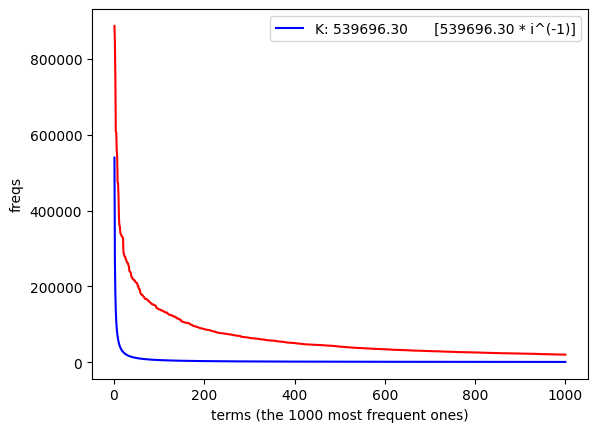

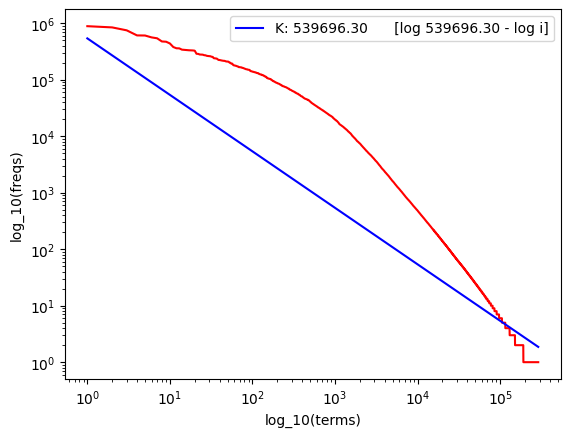

In [5]:
import matplotlib.pyplot as plt
%matplotlib inline

import numpy as np


def plot_Zip_law(dict):

    freqs = [int(v[0]) for v in dict.values()]  # take the cf of each vocabulary term
    freqs.sort(reverse=True)                    # values of Y axis: cf_1, cf_2, cf_3, ....
    x = [i for i in range(1,len(freqs)+1)]      # values of X axis: i = 1, 2, 3, ...


    # log-log transformation
    x1 = np.log10(x)
    y1 = np.log10(freqs)


    # Zip law, fixed "slope" of -1 for the straight line in log-log
    slope = -1
    # Y = - X + intercept =>
    # Y + X = intercept
    # For each pair (x1[i], y1[i]), by substituting in the previos equation, we have:
    #     y1[i] + x1[i] = intercept <= the constant 'intercept' is unknown, and thus differ for
    # each pair (x1[i], y1[i])

    # To fit the straight line  Y = - X + intercept, determine the "intercept" by averaging among all
    # pairs (x1[i], y1[i]) for all i:
    intercept = np.mean(y1 + x1)   # intercept = log(K) (in log.log)

    # 10^(log10(cf)) = 10^(-log10(i) + intercept)
    # cf = 10^(-log10(i)) * 10^(intercept)
    # cf = -i * 10^(intercept)
    fitted_f = [(elx**slope) * (10**intercept) for elx in x]


    # plot the long tail, without log/log transformation
    plt.figure(1)
    plt.xlabel('terms (the 1000 most frequent ones)')
    plt.ylabel('freqs')
    lab = 'K: %.2f' % (10**intercept) + '      [' + '%.2f' % (10**intercept) + ' * i^(-1)]'
    plt.plot(x[:1000], freqs[:1000], 'r')
    plt.plot(x[:1000], fitted_f[:1000], 'b', label=lab)
    plt.legend()
    plt.show()

    # plot the same figure in log.log
    plt.figure(2)
    plt.xlabel('log_10(terms)')
    plt.ylabel('log_10(freqs)')
    lab = 'K: %.2f' % (10**intercept) + '      [' + 'log %.2f' % (10**intercept) + ' - log i]'
    plt.loglog(x, freqs, 'r')
    plt.loglog(x, fitted_f, 'b', label=lab)
    plt.legend()
    plt.show()



plot_Zip_law(dict)




# Clustering documents to compress inverted index

How can we assign document identifiers (**DocIDs**) to the collection's documents for better compressing an inverted file index?

A popular idea is to perform a clustering on the document collection and assign **close DocIDs** to **similar documents**.

A technique proposed in the literature is based on the travelling salesman problem (TSP). The heuristic computes a *pairwise distance* between every pairs of documents (proportional to the number of shared terms, e.g., **Jaccard distance** = *1 - JaccardSim*), and then finds the shorthed path traversing the documents in the graph. The suboptimal cycle found is ﬁnally broken at somepoint, and the DocIDs are reassigned to the documents according to the ordering established by the cycle.
The rationale is that since the cycle preferably traverses edges connecting documents sharing a lot of terms (characterized by a small Jaccard distance), if we assign close DocIDs to these documents, we  expect a reduction in the average value of *d-gaps*, and thus in the size of the compressed inverted index

However, this TSP approach doesn't scale.

To re-assign DocIDs to documents, I suggest the following heuristic method, which at the end exploits TSP to reorder clusters (rather than single documents).
The clustering algorithm scan linearly the documents, sorted in reverse order of length.
Each cluster returned is identified by a **medoid**, which should be a document (belonging to a cluster) that represents all the others in the cluster - i.e., the medoid should be the most centrally located point in the cluster.
However, the  stream clustering algorithm does not guarantee this property of medoids.

1. Transform each document into a **set of termIDs**
2. Reorder the collection according to the document length (in reverse order) and scan linearly the collection of document to clustering them using the **Jaccard distance** = **1 - JaccardSim**:
<br> `C = Stream_cluster(SortedCollection, Radius)`<br>
where C is the returned set of clusters, where a document within each cluster is its Medoid.
4. Apply TSP to the Medoids of each cluster, using the *Jaccard distances* between each pair of Medoids
5. Assign the DocIds linearly *cluster by cluster*, using the TSP-induced order. Within each cluster the order is arbitrary.
6. For each **postings list**, reassign the docIDs, compute the *d-gaps*, and determine the total size of all postings lists. It is not needed to materialize the compressed posting lists, but it suffices to determine the **average bits per d-gap**.

The hyperparameter `Radius` is the maximum distance of each document assigned to a cluster from its medoid. If we reduce the radius of clusters, the cardinality of *C* increases, as the collection is partitioned in more clusters. Increasing *|C|*, the computational time increases as well.
Note that a radius of 1 is the maximum possible distance in terms of **Jaccard distance**, and it occurs when two documents don't have any terms in common.

The pseudo-code of the stream algorithm that visits each document only once is the following:

```
Stream_cluster(SortedCollection, Radius)`
     C = EmptySet
     for each d in SortedCollection
         Dist_c = Min (JaccardDistance(c, d), for each medoid c in C)
         if (Dist_c < radius) then
             add d to cluster c
         else
             make d a new medoid, and add this singleton cluster to C
     return C
```

An alternative version with two scans, which is a tradeoff betwwen the capability of generating more clusters and the associated computational burden, is the following:
```
    inizialize Radius1 and Radius2, where Radius1 > Radius2

    C = EmptySet
	C_tmp = Stream_cluster(SortedCollection, Radius1)
	foreach c in C_tmp:
		C_c = Stream_cluster(c, Radius2)
        C = C setunion C_c
```
The method produces a sort of hierarchical cluster, even if at the end it generates a flat clustering `C`, on whose medoids we apply TSP.












In [7]:
# ── Step 1: Build termID mapping and doc_sets ────────────────────────────────
# 'dict' is the SPIMI index: { term: [cf, [docid1, docid2, ...]] }
# I build:
#   term_to_id  : { term -> termID }
#   doc_sets    : { docID -> frozenset of termIDs }

from collections import defaultdict

# Map each vocabulary term to a unique integer ID
term_to_id = {term: idx for idx, term in enumerate(dict.keys())}
print(f"Vocabulary size: {len(term_to_id)} terms")

# Invert posting lists to build per-document term sets
doc_sets = defaultdict(set)
for term, (cf, postings) in dict.items():
    tid = term_to_id[term]
    for docid in postings:
        doc_sets[docid].add(tid)

# Convert to frozensets (immutable + faster intersection)
doc_sets = {docid: frozenset(terms) for docid, terms in doc_sets.items()}

print(f"Total documents: {len(doc_sets)}")

Vocabulary size: 289294 terms
Total documents: 806792


In [9]:
# ── Step 2: Stream Clustering ─────────────────────────────────────────────────
# Documents are scanned in reverse order of length (longest first),
# so that the first medoids are the richest documents.
#
# For each document d:
#   - compute Jaccard distance to every existing medoid
#   - if the closest medoid is within Radius → assign d to that cluster
#   - otherwise → d becomes a new medoid (singleton cluster)
#
# Parameters:
#   sorted_docids : list of docIDs sorted by descending document length
#   doc_sets      : { docID -> frozenset of termIDs }
#   radius        : max Jaccard distance to assign a doc to an existing cluster
#                   radius=1.0 → all docs in one cluster
#                   radius=0.0 → every doc is its own cluster
#
# Returns:
#   clusters : list of lists  – clusters[i] = [docid, ...]
#   medoids  : list of docIDs – medoids[i]  = medoid of cluster i

import time

def jaccard_distance(set_a, set_b):
    """Jaccard distance = 1 - |A∩B| / |A∪B|. Returns 1.0 if both sets are empty."""
    if not set_a and not set_b:
        return 1.0
    intersection = len(set_a & set_b)
    union        = len(set_a | set_b)
    return 1.0 - intersection / union


def stream_cluster(sorted_docids, doc_sets, radius):
    clusters         = []
    medoids          = []
    term_to_clusters = defaultdict(list)
    total            = len(sorted_docids)

    for idx, docid in enumerate(sorted_docids):
        # Progress print every 10,000 docs
        if idx % 10000 == 0:
            print(f"  {idx}/{total} docs processed, {len(clusters)} clusters so far...")

        d_set = doc_sets[docid]

        # Only compare with medoids that share at least one term
        candidate_clusters = set()
        for tid in d_set:
            for ci in term_to_clusters[tid]:
                candidate_clusters.add(ci)

        best_dist    = float('inf')
        best_cluster = -1

        for ci in candidate_clusters:
            dist = jaccard_distance(d_set, doc_sets[medoids[ci]])
            if dist < best_dist:
                best_dist    = dist
                best_cluster = ci

        if best_cluster >= 0 and best_dist < radius:
            clusters[best_cluster].append(docid)
        else:
            new_ci = len(medoids)
            medoids.append(docid)
            clusters.append([docid])
            for tid in d_set:
                term_to_clusters[tid].append(new_ci)

    return clusters, medoids

# Sort docIDs by descending document length (number of unique terms)
sorted_docids = sorted(doc_sets.keys(), key=lambda d: len(doc_sets[d]), reverse=True)

RADIUS = 0.8

t0 = time.time()
clusters, medoids = stream_cluster(sorted_docids, doc_sets, RADIUS)
elapsed = time.time() - t0

print(f"Radius          : {RADIUS}")
print(f"Clusters        : {len(clusters)}")
print(f"Time            : {elapsed:.1f} s")
print(f"Largest cluster : {max(len(c) for c in clusters)} docs")
print(f"Avg cluster size: {sum(len(c) for c in clusters)/len(clusters):.1f} docs")

  0/806792 docs processed, 0 clusters so far...
  10000/806792 docs processed, 4721 clusters so far...
  20000/806792 docs processed, 8554 clusters so far...
  30000/806792 docs processed, 11841 clusters so far...
  40000/806792 docs processed, 15053 clusters so far...
  50000/806792 docs processed, 18112 clusters so far...
  60000/806792 docs processed, 21071 clusters so far...
  70000/806792 docs processed, 24027 clusters so far...
  80000/806792 docs processed, 26949 clusters so far...
  90000/806792 docs processed, 29922 clusters so far...
  100000/806792 docs processed, 32886 clusters so far...
  110000/806792 docs processed, 35871 clusters so far...
  120000/806792 docs processed, 38811 clusters so far...


KeyboardInterrupt: 

In [ ]:
def two_scan_cluster(sorted_docids, doc_sets, radius1, radius2):
    # Two-scan stream clustering.
    # First scan with radius1 (larger), second scan with radius2 (smaller).
    # radius1 > radius2
    # This produces a finer-grained clustering than single-scan.
    C_tmp, _ = stream_cluster(sorted_docids, doc_sets, radius1)
    C_final  = []
    M_final  = []
    for cluster in C_tmp:
        sub_clusters, sub_medoids = stream_cluster(cluster, doc_sets, radius2)
        C_final.extend(sub_clusters)
        M_final.extend(sub_medoids)
    return C_final, M_final

In [ ]:
# ── Step 3: Greedy Nearest-Neighbour TSP on Medoids ──────────────────────────
# After clustering, I have a set of medoids, one per cluster.
# I apply a greedy nearest-neighbour TSP heuristic to find an ordering
# of the clusters such that adjacent clusters share many terms.
#
# Algorithm:
#   1. Start from the medoid with the most terms (richest document)
#   2. Repeatedly visit the closest unvisited medoid (by Jaccard distance)
#   3. Return the ordered list of cluster indices
#
# This ordering will be used to assign consecutive DocIDs to similar clusters,
# reducing d-gaps in the posting lists and improving compression.
#
# Parameters:
#   medoids  : list of docIDs, one per cluster
#   doc_sets : { docID -> frozenset of termIDs }
#
# Returns:
#   order : list of cluster indices in TSP-induced order

import time

def greedy_tsp(medoids, doc_sets):
    n = len(medoids)
    if n == 1:
        return [0]

    visited = [False] * n

    # Start from the richest medoid (most terms)
    start = max(range(n), key=lambda i: len(doc_sets[medoids[i]]))
    order = [start]
    visited[start] = True

    for _ in range(n - 1):
        last     = order[-1]
        last_set = doc_sets[medoids[last]]

        best_dist = float('inf')
        best_next = -1

        for j in range(n):
            if not visited[j]:
                d = jaccard_distance(last_set, doc_sets[medoids[j]])
                if d < best_dist:
                    best_dist = d
                    best_next = j

        order.append(best_next)
        visited[best_next] = True

    return order


t0 = time.time()
tsp_order = greedy_tsp(medoids, doc_sets)
elapsed = time.time() - t0

print(f"TSP on {len(medoids)} medoids completed in {elapsed:.2f} s")
print(f"First 10 cluster indices in TSP order: {tsp_order[:10]}")

In [ ]:
# ── Step 4: Assign new DocIDs ─────────────────────────────────────────────────
# I assign new consecutive DocIDs cluster by cluster,
# following the TSP-induced order.
#
# Within each cluster the order is arbitrary (as the spec allows).
#
# new_docid[old_docid] = new_docid
#
# Example:
#   TSP order : [0, 2, 1, 3]
#   Cluster 0 : [23, 7, 44, 4]   → new DocIDs: 1, 2, 3, 4
#   Cluster 2 : [55, 12]         → new DocIDs: 5, 6
#   Cluster 1 : [1, 99]          → new DocIDs: 7, 8
#   Cluster 3 : [88]             → new DocID : 9

new_docid = {}
counter = 1

for cluster_idx in tsp_order:
    for old_id in clusters[cluster_idx]:
        new_docid[old_id] = counter
        counter += 1

print(f"Reassigned {len(new_docid)} DocIDs across {len(tsp_order)} clusters")
print(f"Example: old docID 1 -> new docID {new_docid.get(1, 'N/A')}")

In [ ]:
# ── Step 5: Compression Comparison ───────────────────────────────────────────
# I compute average bits per posting using three encoding schemes,
# before and after DocID reassignment.
#
# For each posting list:
#   1. Remap old DocIDs to new DocIDs using new_docid map
#   2. Sort the remapped list
#   3. Compute d-gaps
#   4. Encode each gap with VB, Gamma, Delta
#   5. Sum up total bits and divide by total postings
#
# Encoding schemes:
#   Variable Byte (VB) : ceil((floor(log2(G)) + 1) / 7) * 8
#   Gamma (γ)          : 2 * floor(log2(G)) + 1
#   Delta (δ)          : floor(log2(G)) + 1 + 2 * floor(log2(floor(log2(G)) + 1))

import math, time

def vb_bits(g):
    """Variable Byte bits for gap g (g >= 1)."""
    return math.ceil((math.floor(math.log2(g)) + 1) / 7) * 8

def gamma_bits(g):
    """Elias Gamma bits for gap g (g >= 1)."""
    return 2 * math.floor(math.log2(g)) + 1

def delta_bits(g):
    """Elias Delta bits for gap g (g >= 1)."""
    k = math.floor(math.log2(g)) + 1
    return math.floor(math.log2(g)) + 1 + 2 * math.floor(math.log2(k))


def avg_bits_per_posting(index_dict, docid_map=None):
    """
    Compute average bits per posting for VB, Gamma, Delta.

    Parameters
    ----------
    index_dict : SPIMI dict  { term: [cf, [docid, ...]] }
    docid_map  : if given, remap docIDs before computing d-gaps

    Returns
    -------
    dict with keys 'vb', 'gamma', 'delta', 'total_postings'
    """
    total_vb    = 0
    total_gamma = 0
    total_delta = 0
    total_postings = 0

    for term, (cf, postings) in index_dict.items():
        if docid_map:
            # remap old DocIDs to new DocIDs and sort
            mapped = sorted(docid_map[d] for d in postings if d in docid_map)
        else:
            mapped = postings  # already sorted

        # compute d-gaps and encode
        prev = 0
        for d in mapped:
            gap = d - prev
            total_vb    += vb_bits(gap)
            total_gamma += gamma_bits(gap)
            total_delta += delta_bits(gap)
            prev = d
            total_postings += 1

    n = total_postings
    return {
        "vb"             : total_vb    / n,
        "gamma"          : total_gamma / n,
        "delta"          : total_delta / n,
        "total_postings" : n
    }


print("Computing baseline (original DocIDs) ...")
t0 = time.time()
baseline = avg_bits_per_posting(dict)
print(f"Done in {time.time()-t0:.1f} s")

print("Computing after DocID reassignment ...")
t0 = time.time()
reassigned = avg_bits_per_posting(dict, docid_map=new_docid)
print(f"Done in {time.time()-t0:.1f} s")

print()
print(f"{'Encoding':<10} {'Baseline':>12} {'Reassigned':>14} {'Improvement':>14}")
print("-" * 54)
for enc in ["vb", "gamma", "delta"]:
    b   = baseline[enc]
    r   = reassigned[enc]
    imp = (b - r) / b * 100
    print(f"{enc.upper():<10} {b:>12.3f} {r:>14.3f} {imp:>13.2f}%")
print(f"\nTotal postings: {baseline['total_postings']:,}")

In [ ]:
# ── Step 6.1: Write VB-compressed binary index and measure decompression time ───
# I store the index in a compressed binary format using Variable Byte encoding.
# Two files are created:
#   lexicon_vb.idx  : text file  →  term  cf  df  byte_offset  byte_length
#   postings_vb.bin : binary file → concatenated VB-encoded posting lists
#
# Then we measure the decompression time for the top-100 most frequent terms.
#
# VB encode:
#   - split gap into 7-bit groups
#   - set the MSB of the last byte to 1 (continuation bit)
#
# VB decode:
#   - read bytes until MSB=1
#   - reconstruct gap from 7-bit groups
#   - add gap to previous docID to get current docID

import os, time, io

def vb_encode_list(docids, docid_map=None):
    """
    Encode a posting list as Variable Byte bytes.
    Converts to d-gaps first; optionally remaps docIDs.
    """
    if docid_map:
        mapped = sorted(docid_map[d] for d in docids if d in docid_map)
    else:
        mapped = docids

    buf = io.BytesIO()
    prev = 0
    for d in mapped:
        gap = d - prev
        prev = d
        # VB encode gap into 7-bit groups
        bytes_out = []
        while True:
            bytes_out.insert(0, gap & 0x7F)  # take last 7 bits
            gap >>= 7                          # shift right 7 bits
            if gap == 0:
                break
        bytes_out[-1] |= 0x80  # set MSB of last byte to 1
        buf.write(bytes(bytes_out))
    return buf.getvalue()


def vb_decode_list(data):
    """Decode Variable Byte bytes back to a sorted list of docIDs."""
    result = []
    gap  = 0
    prev = 0
    for byte in data:
        if byte & 0x80:               # MSB=1 → last byte of this gap
            gap = (gap << 7) | (byte & 0x7F)
            prev += gap
            result.append(prev)
            gap = 0
        else:                         # MSB=0 → more bytes coming
            gap = (gap << 7) | byte
    return result


def write_vb_index(index_dict, docid_map, lexicon_path, postings_path):
    """
    Write VB-compressed binary index to disk.
    lexicon_path  : text file  term cf df byte_offset byte_length
    postings_path : binary file of concatenated VB-encoded posting lists
    """
    with open(lexicon_path, "w") as lex, open(postings_path, "wb") as post:
        byte_offset = 0
        for term in sorted(index_dict.keys()):
            cf, postings = index_dict[term]
            df      = len(postings)
            encoded = vb_encode_list(postings, docid_map)
            byte_len = len(encoded)
            lex.write(f"{term} {cf} {df} {byte_offset} {byte_len}\n")
            post.write(encoded)
            byte_offset += byte_len


# ── Write index to disk ───────────────────────────────────────────────────────
print("Writing VB-compressed binary index ...")
t0 = time.time()
write_vb_index(dict, new_docid, "lexicon_vb.idx", "postings_vb.bin")
elapsed = time.time() - t0
size_mb = os.path.getsize("postings_vb.bin") / 1024 / 1024
print(f"Done in {elapsed:.1f} s  |  postings_vb.bin = {size_mb:.1f} MB")


# ── Measure decompression time for top-100 most frequent terms ────────────────
print("\nLoading lexicon ...")
vb_lexicon = {}
with open("lexicon_vb.idx") as f:
    for line in f:
        parts = line.split()
        vb_lexicon[parts[0]] = (int(parts[1]), int(parts[2]),
                                 int(parts[3]), int(parts[4]))
        # term → (cf, df, byte_offset, byte_length)

# Sort by df descending → top-100 most frequent terms
top100 = sorted(vb_lexicon.items(), key=lambda x: x[1][1], reverse=True)[:100]

print("Measuring decompression time for top-100 terms ...")
decomp_times = []
with open("postings_vb.bin", "rb") as post_file:
    for term, (cf, df, offset, length) in top100:
        post_file.seek(offset)
        data = post_file.read(length)
        t0 = time.perf_counter()
        decoded = vb_decode_list(data)
        elapsed_us = (time.perf_counter() - t0) * 1e6
        decomp_times.append((term, df, elapsed_us))

avg_us = sum(t for _, _, t in decomp_times) / len(decomp_times)
print(f"\nAverage decompression time (top-100): {avg_us:.1f} µs")
print()
print(f"{'Term':<20} {'df':>10} {'Decomp (µs)':>14}")
print("-" * 48)
for term, df, t in decomp_times[:20]:
    print(f"{term:<20} {df:>10,} {t:>14.1f}")

In [ ]:
# ── Step 6.2: PForDelta encode / decode ────────────────────────────────────────
# PForDelta encodes gaps in blocks of 128.
# For each block:
#   1. Find the minimum number of bits (b) that covers 90% of the gaps
#   2. Encode all gaps that fit in b bits directly (fixed-width)
#   3. Store exceptions (gaps that don't fit) separately
#
# Block structure:
#   [b (1 byte)] [128 x b-bit values] [n_exceptions (1 byte)] [exceptions as VB]
import math, io, os, time

BLOCK_SIZE = 128

def pfordelta_encode_block(gaps):
    """Encode a single block of gaps using PForDelta."""
    buf = io.BytesIO()

    # Find b: minimum bits covering 90% of gaps
    sorted_gaps = sorted(gaps)
    threshold_idx = int(len(sorted_gaps) * 0.9)
    threshold_val = sorted_gaps[min(threshold_idx, len(sorted_gaps) - 1)]

    b = max(1, math.floor(math.log2(threshold_val + 1)) + 1) if threshold_val > 0 else 1
    max_val = (1 << b) - 1  # maximum value that fits in b bits

    # Separate normal values and exceptions
    normals    = []
    exceptions = []
    for i, g in enumerate(gaps):
        if g <= max_val:
            normals.append(g)
            exceptions.append(None)
        else:
            normals.append(max_val)  # placeholder
            exceptions.append((i, g))

    # Write b
    buf.write(bytes([b]))

    # Write normal values as fixed-width b-bit integers
    # Pack into bytes
    bit_buf  = 0
    bit_count = 0
    for val in normals:
        bit_buf   = (bit_buf << b) | val
        bit_count += b
        while bit_count >= 8:
            bit_count -= 8
            buf.write(bytes([(bit_buf >> bit_count) & 0xFF]))
    if bit_count > 0:
        buf.write(bytes([(bit_buf << (8 - bit_count)) & 0xFF]))

    # Write exceptions as VB-encoded (index, value) pairs
    real_exceptions = [(i, g) for i, g in exceptions if g is not None]
    buf.write(bytes([len(real_exceptions)]))
    for idx, val in real_exceptions:
        for x in [idx, val]:
            bytes_out = []
            while True:
                bytes_out.insert(0, x & 0x7F)
                x >>= 7
                if x == 0:
                    break
            bytes_out[-1] |= 0x80
            buf.write(bytes(bytes_out))

    return buf.getvalue(), b


def pfordelta_decode_block(data, offset, n):
    """Decode a PForDelta block of n gaps starting at byte offset."""
    b = data[offset]
    offset += 1

    # Read n fixed-width b-bit values
    normals   = []
    bit_buf   = 0
    bit_count = 0
    i         = 0
    while len(normals) < n:
        while bit_count < b:
            bit_buf    = (bit_buf << 8) | data[offset]
            bit_count += 8
            offset    += 1
        bit_count -= b
        normals.append((bit_buf >> bit_count) & ((1 << b) - 1))

    # Read exceptions
    n_exc  = data[offset]
    offset += 1
    gaps   = list(normals)

    for _ in range(n_exc):
        # decode index (VB)
        idx = 0
        while True:
            byte    = data[offset]; offset += 1
            idx     = (idx << 7) | (byte & 0x7F)
            if byte & 0x80:
                break
        # decode value (VB)
        val = 0
        while True:
            byte    = data[offset]; offset += 1
            val     = (val << 7) | (byte & 0x7F)
            if byte & 0x80:
                break
        gaps[idx] = val

    return gaps, offset


def pfordelta_encode_list(docids, docid_map=None):
    """Encode a full posting list using PForDelta."""
    if docid_map:
        mapped = sorted(docid_map[d] for d in docids if d in docid_map)
    else:
        mapped = docids

    # Compute d-gaps
    gaps = []
    prev = 0
    for d in mapped:
        gaps.append(d - prev)
        prev = d

    buf = io.BytesIO()
    # Write total number of postings (4 bytes)
    buf.write(len(gaps).to_bytes(4, 'little'))

    # Encode block by block
    for start in range(0, len(gaps), BLOCK_SIZE):
        block = gaps[start:start + BLOCK_SIZE]
        encoded_block, _ = pfordelta_encode_block(block)
        # Write block size (1 byte) + encoded block
        buf.write(len(block).to_bytes(1, 'little'))
        buf.write(encoded_block)

    return buf.getvalue()


def pfordelta_decode_list(data):
    """Decode a PForDelta-encoded posting list."""
    n_postings = int.from_bytes(data[0:4], 'little')
    offset     = 4
    gaps       = []

    while len(gaps) < n_postings:
        block_size = data[offset]; offset += 1
        block_gaps, offset = pfordelta_decode_block(data, offset, block_size)
        gaps.extend(block_gaps)

    # Reconstruct docIDs from gaps
    result = []
    prev   = 0
    for g in gaps:
        prev += g
        result.append(prev)
    return result


def write_pfordelta_index(index_dict, docid_map, lexicon_path, postings_path):
    """Write PForDelta-compressed binary index to disk."""
    with open(lexicon_path, "w") as lex, open(postings_path, "wb") as post:
        byte_offset = 0
        for term in sorted(index_dict.keys()):
            cf, postings = index_dict[term]
            df           = len(postings)
            encoded      = pfordelta_encode_list(postings, docid_map)
            byte_len     = len(encoded)
            lex.write(f"{term} {cf} {df} {byte_offset} {byte_len}\n")
            post.write(encoded)
            byte_offset += byte_len


# ── Write PForDelta index to disk ─────────────────────────────────────────────
print("Writing PForDelta-compressed binary index ...")
t0 = time.time()
write_pfordelta_index(dict, new_docid, "lexicon_pfd.idx", "postings_pfd.bin")
elapsed  = time.time() - t0
size_mb  = os.path.getsize("postings_pfd.bin") / 1024 / 1024
print(f"Done in {elapsed:.1f} s  |  postings_pfd.bin = {size_mb:.1f} MB")


# ── Compare decompression time: VB vs PForDelta ───────────────────────────────
print("\nLoading lexicons ...")

pfd_lexicon = {}
with open("lexicon_pfd.idx") as f:
    for line in f:
        parts = line.split()
        pfd_lexicon[parts[0]] = (int(parts[1]), int(parts[2]),
                                  int(parts[3]), int(parts[4]))

# Top-100 terms by df
top100_terms = sorted(vb_lexicon.items(), key=lambda x: x[1][1], reverse=True)[:100]

print("Measuring decompression time: VB vs PForDelta ...")
print()
print(f"{'Term':<20} {'df':>8} {'VB (µs)':>12} {'PFD (µs)':>12}")
print("-" * 56)

vb_times   = []
pfd_times  = []

with open("postings_vb.bin",  "rb") as vb_file, \
     open("postings_pfd.bin", "rb") as pfd_file:

    for term, (cf, df, vb_offset, vb_len) in top100_terms:

        # VB decode
        vb_file.seek(vb_offset)
        vb_data = vb_file.read(vb_len)
        t0      = time.perf_counter()
        _       = vb_decode_list(vb_data)
        vb_us   = (time.perf_counter() - t0) * 1e6
        vb_times.append(vb_us)

        # PForDelta decode
        pfd_cf, pfd_df, pfd_offset, pfd_len = pfd_lexicon[term]
        pfd_file.seek(pfd_offset)
        pfd_data = pfd_file.read(pfd_len)
        t0       = time.perf_counter()
        _        = pfordelta_decode_list(pfd_data)
        pfd_us   = (time.perf_counter() - t0) * 1e6
        pfd_times.append(pfd_us)

        print(f"{term:<20} {df:>8,} {vb_us:>12.1f} {pfd_us:>12.1f}")

print("-" * 56)
print(f"{'Average':<20} {'':>8} {sum(vb_times)/len(vb_times):>12.1f} "
      f"{sum(pfd_times)/len(pfd_times):>12.1f}")

vb_size_mb  = os.path.getsize("postings_vb.bin")  / 1024 / 1024
pfd_size_mb = os.path.getsize("postings_pfd.bin") / 1024 / 1024
print()
print(f"VB  index size : {vb_size_mb:.1f} MB")
print(f"PFD index size : {pfd_size_mb:.1f} MB")

In [ ]:
# ── Step 7: Compression Rate vs. Number of Clusters (Radius Sweep) ────────────
# I sweep the Radius hyperparameter to show how clustering quality
# affects compression rate and execution time.
#
# For each radius:
#   1. Run stream_cluster → get clusters and medoids
#   2. Run greedy_tsp → get TSP order
#   3. Assign new DocIDs
#   4. Compute avg bits/posting for VB, Gamma, Delta
#   5. Record execution time and number of clusters
#
# Expected results:
#   - smaller radius → more clusters → better compression → slower
#   - larger radius  → fewer clusters → worse compression → faster

import time
import matplotlib.pyplot as plt

RADII = [0.95, 0.90, 0.85, 0.80, 0.75, 0.70]

results_two_scan = []

for radius in RADII:
    radius1 = min(radius + 0.1, 0.99)
    radius2 = radius
    t0 = time.time()
    c, m = two_scan_cluster(sorted_docids, doc_sets, radius1, radius2)
    cluster_time = time.time() - t0
    t1 = time.time()
    tsp_ord = greedy_tsp(m, doc_sets)
    tsp_time = time.time() - t1
    nd = {}
    counter = 1
    for ci in tsp_ord:
        for old_id in c[ci]:
            nd[old_id] = counter
            counter += 1
    metrics = avg_bits_per_posting(dict, docid_map=nd)
    total_time = cluster_time + tsp_time
    results_two_scan.append({
        "radius"    : radius,
        "n_clusters": len(c),
        "time_s"    : total_time,
        "vb"        : metrics["vb"],
        "gamma"     : metrics["gamma"],
        "delta"     : metrics["delta"],
    })
    print(f"[TwoScan] Radius={radius:.2f}  clusters={len(c):6,}  time={total_time:6.1f}s  "
          f"VB={metrics['vb']:.3f}  Gamma={metrics['gamma']:.3f}  Delta={metrics['delta']:.3f}")

results = []

for radius in RADII:
    # ── Clustering ────────────────────────────────────────────────────────────
    t0 = time.time()
    c, m = stream_cluster(sorted_docids, doc_sets, radius)
    cluster_time = time.time() - t0

    # ── TSP ──────────────────────────────────────────────────────────────────
    t1 = time.time()
    tsp_ord = greedy_tsp(m, doc_sets)
    tsp_time = time.time() - t1

    # ── DocID reassignment ────────────────────────────────────────────────────
    nd = {}
    counter = 1
    for ci in tsp_ord:
        for old_id in c[ci]:
            nd[old_id] = counter
            counter += 1

    # ── Compression metrics ───────────────────────────────────────────────────
    metrics = avg_bits_per_posting(dict, docid_map=nd)
    total_time = cluster_time + tsp_time

    results.append({
        "radius"    : radius,
        "n_clusters": len(c),
        "time_s"    : total_time,
        "vb"        : metrics["vb"],
        "gamma"     : metrics["gamma"],
        "delta"     : metrics["delta"],
    })

    print(f"Radius={radius:.2f}  clusters={len(c):6,}  time={total_time:6.1f}s  "
          f"VB={metrics['vb']:.3f}  Gamma={metrics['gamma']:.3f}  Delta={metrics['delta']:.3f}")

# ── Plot ──────────────────────────────────────────────────────────────────────
n_clusters = [r["n_clusters"] for r in results]

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Compression rate vs clusters
for enc, color in [("vb","steelblue"), ("gamma","darkorange"), ("delta","green")]:
    axes[0].plot(n_clusters, [r[enc] for r in results],
                 marker="o", label=enc.upper(), color=color)

n_clusters_two = [r["n_clusters"] for r in results_two_scan]
for enc, color in [("vb","steelblue"), ("gamma","darkorange"), ("delta","green")]:
    axes[0].plot(n_clusters_two, [r[enc] for r in results_two_scan],
                 marker="^", linestyle="--", label=f"{enc.upper()} (2-scan)", color=color, alpha=0.7)

axes[1].plot(n_clusters_two, [r["time_s"] for r in results_two_scan],
             marker="^", linestyle="--", color="crimson", alpha=0.7, label="Two-scan")
axes[1].plot(n_clusters, [r["time_s"] for r in results],
             marker="s", color="crimson", label="Single-scan")
axes[1].legend()

axes[0].axhline(baseline["vb"],    linestyle="--", color="steelblue",
                alpha=0.5, label="Baseline VB")
axes[0].axhline(baseline["gamma"], linestyle="--", color="darkorange",
                alpha=0.5, label="Baseline Gamma")
axes[0].axhline(baseline["delta"], linestyle="--", color="green",
                alpha=0.5, label="Baseline Delta")
axes[0].set_xlabel("Number of clusters")
axes[0].set_ylabel("Avg bits per posting")
axes[0].set_title("Compression rate vs. Number of clusters")
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Execution time vs clusters
axes[1].set_xlabel("Number of clusters")
axes[1].set_ylabel("Execution time (s)")
axes[1].set_title("Execution time vs. Number of clusters")
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("compression_vs_clusters.png", dpi=120)
plt.show()
print("Plot saved to compression_vs_clusters.png")